 Task-01: Take a 5x6 NumPy array and plot the histogram of the arrray with proper labels (with and without built in histogram function). Show both histograms side by side in a subplot with a title. Show input NumPy array into an image.  

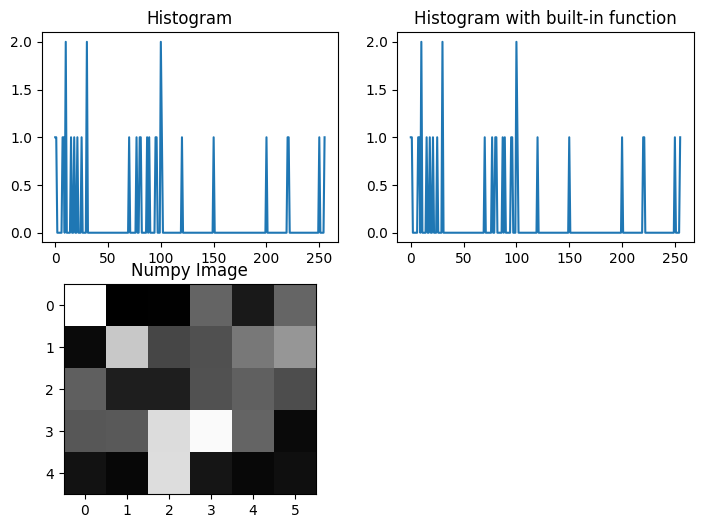

Histogram Summary: 
Total Pixels: 30
Unique Intensity Values: 27
Most Frequent pixel value: 10 (Count: 2.0)
Least Frequent pixel Pixel Value: 0 (Count: 1.0)
Mean Intensity: 85.57
Median intensity: 80.5
Standard Deviation of intensity: 76.04


In [22]:
import cv2
import numpy as np
import matplotlib.pyplot as plt


array=np.array([
    [255,0,1,100,25,101],
    [10,200,70,80,120,150],
    [95,30,30,81,96,77],
    [87,89,220,250,100,10],
    [18,7,221,21,8,15]
])


hist=np.zeros(256)


for i in range(array.shape[0]):
  for j in range(array.shape[1]):
    hist[array[i,j]]+=1


hist2,bins=np.histogram(array,256,[0,256])


plt.figure(figsize=(13,6))
plt.subplot(2,3,1)
plt.plot(hist)
plt.title('Histogram')


plt.subplot(2,3,2)
plt.plot(hist2)
plt.title('Histogram with built-in function')


plt.subplot(2,3,4)
plt.imshow(array,cmap='gray')
plt.title('Numpy Image')
plt.show()


total_pixels=array.size
unique_values=np.count_nonzero(hist)


most_freq_val=np.argmax(hist)
most_freq_count=hist[most_freq_val]
nonzero_hist=hist[hist>0]


least_freq_val=np.where(hist==nonzero_hist.min())[0][0]
least_freq_count=hist[least_freq_val]


mean_intensity=np.mean(array)
median_intensity=np.median(array)
std_intensity=np.std(array)


print("Histogram Summary: ")
print(f"Total Pixels: {total_pixels}")
print(f"Unique Intensity Values: {unique_values}")
print(f"Most Frequent pixel value: {most_freq_val} (Count: {most_freq_count})")
print(f"Least Frequent pixel Pixel Value: {least_freq_val} (Count: {least_freq_count})")
print(f"Mean Intensity: {mean_intensity:.2f}")
print(f"Median intensity: {median_intensity}")
print(f"Standard Deviation of intensity: {std_intensity:.2f}")








#

 Task-02: Take an 8-bit grayscale image and plot the histogram of the image with proper labels(with an without built in histogram function). Show both histogram side by side in a subplot with a title.

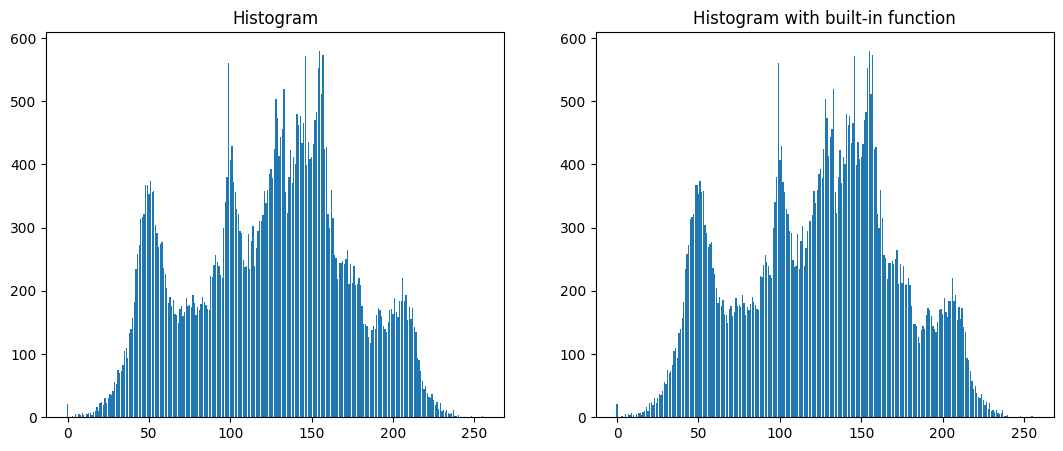

Histogram Summary for Grayscale Image: 
Total Pixels: 50625
Unique Intensity Values: 246
Most Frequent pixel value: 155 (Count: 580.0)
Least Frequent pixel Pixel Value: 1 (Count: 1.0)
Mean Intensity: 123.82
Median intensity: 129.0
Standard Deviation of intensity: 48.22


In [24]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img=cv2.imread('/content/drive/MyDrive/cse 3216/gray_img.jpg')
hist=np.zeros(256)

for i in range(array.shape[0]):
  for j in range(array.shape[1]):
    hist[array[i,j]]+=1

hist2,bins=np.histogram(img,256,[0,256])
img_gray=cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)
hist=np.zeros(256)

for i in range(img_gray.shape[0]):
  for j in range(img_gray.shape[1]):
    hist[img_gray[i,j]]+=1

hist2,bins=np.histogram(img_gray,256,[0,256])

plt.figure(figsize=(13,5))
plt.subplot(1,2,1)
plt.bar(range(256), hist)
plt.title("Histogram")

plt.subplot(1,2,2)
plt.bar(range(256), hist2)
plt.title("Histogram with built-in function")

plt.show()

total_pixels=img_gray.size
unique_values=np.count_nonzero(hist)
most_freq_val=np.argmax(hist)
most_freq_count=hist[most_freq_val]
nonzero_hist=hist[hist>0]
least_freq_val=np.where(hist==nonzero_hist.min())[0][0]
least_freq_count=hist[least_freq_val]

mean_intensity=np.mean(img_gray)
median_intensity=np.median(img_gray)
std_intensity=np.std(img_gray)

print("Histogram Summary for Grayscale Image: ")
print(f"Total Pixels: {total_pixels}")
print(f"Unique Intensity Values: {unique_values}")
print(f"Most Frequent pixel value: {most_freq_val} (Count: {most_freq_count})")
print(f"Least Frequent pixel Pixel Value: {least_freq_val} (Count: {least_freq_count})")
print(f"Mean Intensity: {mean_intensity:.2f}")
print(f"Median intensity: {median_intensity}")
print(f"Standard Deviation of intensity: {std_intensity:.2f}")

 Task-03: Take an 8-bit grayscale image and plot the histogram equalized image as well as its histogram with proper labels(with and without built in histogram function). Show both histograms side by side in a subplot with a title. Show both equalized image side by side in a subplot with a title.

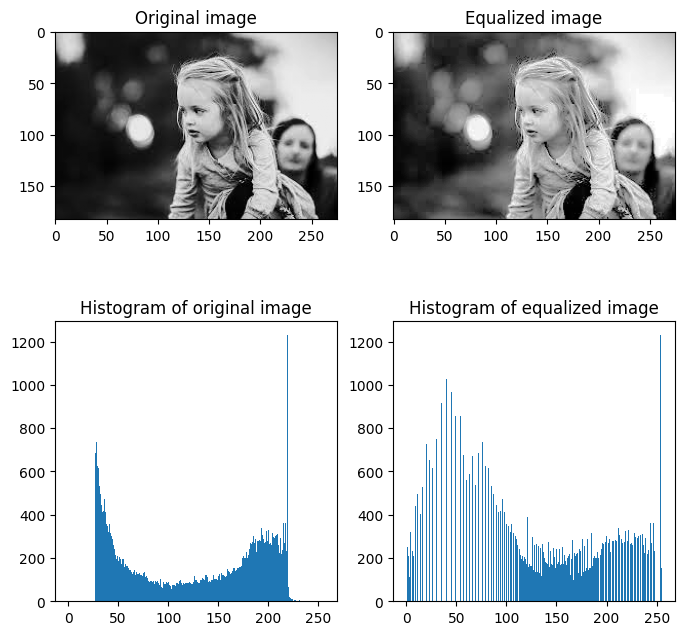

Original Image Histogram: 
Histogram Summary: 
Total Pixels: 50325.0
Unique Intensity Val: 236
Most Frequent Pixel Value: 219 (Count: 1232.0)
Least Frequent Pixel Value: 233 (Count: 1.0)
Mean Intensity: 95.23
Median Intensity: 63
Standard Deviation: 76.20

Equalized Image Histogram: 
Histogram Summary: 
Total Pixels: 50325.0
Unique Intensity Val: 164
Most Frequent Pixel Value: 254 (Count: 1232.0)
Least Frequent Pixel Value: 167 (Count: 100.0)
Mean Intensity: 128.50
Median Intensity: 128
Standard Deviation: 73.28


In [10]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img=cv2.imread('/content/drive/MyDrive/cse 3216/b&w bby.jpeg')
img_gray=cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)


hist=np.zeros(256)
for i in range(img_gray.shape[0]):
    for j in range(img_gray.shape[1]):
        hist[img_gray[i,j]]+=1


cdf=np.zeros(256)
cdf[0]=hist[0]
for i in range(1,256):
    cdf[i]=cdf[i-1]+hist[i]


cdf=cdf*255/cdf[255]


img_eq=np.zeros(img_gray.shape)
for i in range(img_gray.shape[0]):
    for j in range(img_gray.shape[1]):
        img_eq[i,j]=cdf[img_gray[i,j]]


hist1=np.zeros(256)
for i in range(img_eq.shape[0]):
    for j in range(img_eq.shape[1]):
        pixel=round(img_eq[i,j])
        hist1[pixel]+=1


plt.figure(figsize=(8,8))
plt.subplot(2,2,1)
plt.imshow(img_gray,cmap='gray')
plt.title('Original image')


plt.subplot(2,2,2)
plt.imshow(img_eq,cmap='gray')
plt.title('Equalized image')


plt.subplot(2,2,3)
plt.bar(range(256),hist)
plt.title('Histogram of original image')


plt.subplot(2,2,4)
plt.bar(range(256),hist1)
plt.title("Histogram of equalized image")


plt.show()



def histogram_summary(hist_array):
    total_pixels=hist_array.sum()
    unique_values=np.count_nonzero(hist_array)

    most_freq_val=np.argmax(hist_array)
    most_freq_count=hist_array[most_freq_val]
    nonzero_hist=hist_array[hist_array>0]

    least_freq_val=np.where(hist_array==nonzero_hist.min())[0][0]
    least_freq_count=hist_array[least_freq_val]

    mean_intensity=np.average(np.arange(256),weights=hist_array)

    cumulative=np.cumsum(hist_array)

    median_intensity=np.searchsorted(cumulative,total_pixels//2)
    variance=np.average((np.arange(256)-mean_intensity)**2,weights=hist_array)
    std_intensity=np.sqrt(variance)


    print("Histogram Summary: ")
    print(f"Total Pixels: {total_pixels}")
    print(f"Unique Intensity Val: {unique_values}")
    print(f"Most Frequent Pixel Value: {most_freq_val} (Count: {most_freq_count})")
    print(f"Least Frequent Pixel Value: {least_freq_val} (Count: {least_freq_count})")
    print(f"Mean Intensity: {mean_intensity:.2f}")
    print(f"Median Intensity: {median_intensity}")
    print(f"Standard Deviation: {std_intensity:.2f}")


print("Original Image Histogram: ")
histogram_summary(hist)
print("\nEqualized Image Histogram: ")
histogram_summary(hist1)

 Task-04: Take an 8bit grayscale image and a reference image. Write a program to match the histogram of the input image to the reference iamge. Show the original, reference, and matched image side by side. Plot their histograms side by side and overlay gthem in a single graph for comparison. Also, Calculate and display a summary for each image including total pixels, number of unique intensity values, most and least frequent pixel values, mean, median, and standard deviation.

Original Image Histogram:
Total Pixels: 50625.0
Unique Intensity Values: 246
Most Frequent Pixel Value: 155 (Count: 580.0)
Least Frequent Pixel Value: 1 (Count: 1.0)
Mean Intensity: 123.82
Median Intensity: 129
Standard Deviation: 48.22

Reference Image Histogram:
Total Pixels: 50325.0
Unique Intensity Values: 236
Most Frequent Pixel Value: 219 (Count: 1232.0)
Least Frequent Pixel Value: 233 (Count: 1.0)
Mean Intensity: 95.23
Median Intensity: 63
Standard Deviation: 76.20

Matched Image Histogram:
Total Pixels: 50625.0
Unique Intensity Values: 134
Most Frequent Pixel Value: 18 (Count: 1038.0)
Least Frequent Pixel Value: 233 (Count: 1.0)
Mean Intensity: 95.95
Median Intensity: 66
Standard Deviation: 76.28



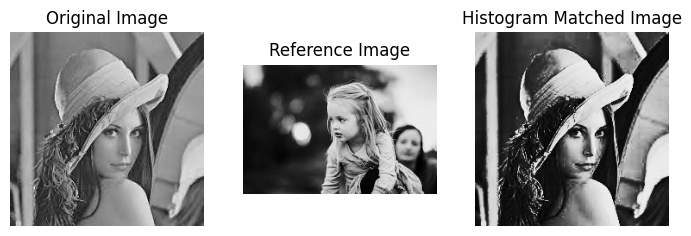

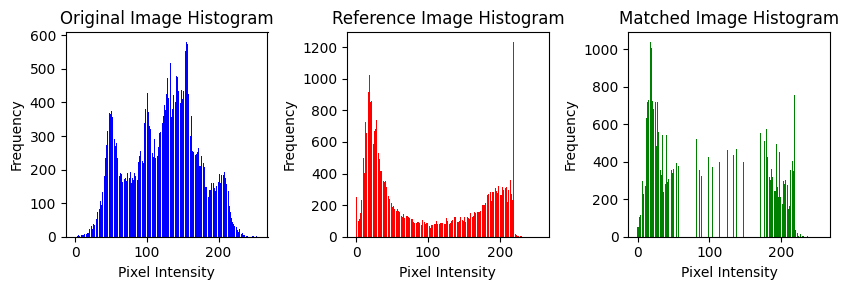

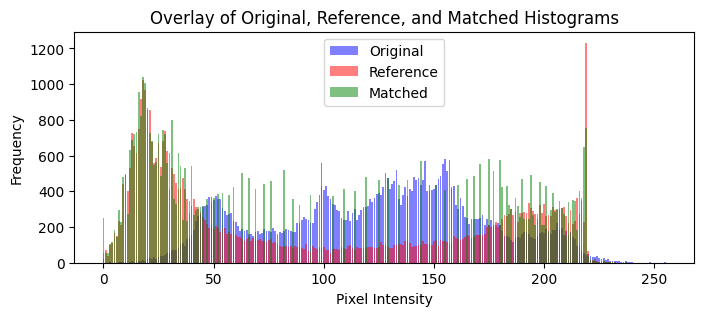

In [36]:
import cv2
import numpy as np
import matplotlib.pyplot as plt


img=cv2.imread('/content/drive/MyDrive/cse 3216/gray_img.jpg', cv2.IMREAD_GRAYSCALE)
ref_img=cv2.imread('/content/drive/MyDrive/cse 3216/b&w bby.jpeg', cv2.IMREAD_GRAYSCALE)


def compute_histogram(image):
    hist=np.zeros(256)
    for i in range(image.shape[0]):
        for j in range(image.shape[1]):
            hist[image[i,j]]+=1
    return hist


hist_img=compute_histogram(img)
hist_ref=compute_histogram(ref_img)


cdf_img=np.cumsum(hist_img)
cdf_ref=np.cumsum(hist_ref)


cdf_img_norm=(cdf_img-cdf_img.min())*255/(cdf_img.max()-cdf_img.min())
cdf_ref_norm=(cdf_ref-cdf_ref.min())*255/(cdf_ref.max()-cdf_ref.min())


lookup_table=np.zeros(256)
for i in range(256):
    diff=np.abs(cdf_img_norm[i]-cdf_ref_norm)
    lookup_table[i]=np.argmin(diff)


matched_img=np.zeros_like(img)
for i in range(img.shape[0]):
    for j in range(img.shape[1]):
        matched_img[i,j]=lookup_table[img[i,j]]



hist_matched=compute_histogram(matched_img)


hist_img_builtin,_=np.histogram(img,bins=256,range=(0,256))
hist_ref_builtin,_=np.histogram(ref_img,bins=256,range=(0,256))
hist_matched_builtin,_=np.histogram(matched_img,bins=256,range=(0,256))




def histogram_summary(hist_array,title="Histogram Summary"):
    total_pixels=hist_array.sum()
    unique_values=np.count_nonzero(hist_array)


    most_freq_value=np.argmax(hist_array)
    most_freq_count=hist_array[most_freq_value]
    nonzero_hist=hist_array[hist_array>0]


    least_freq_value=np.where(hist_array==nonzero_hist.min())[0][0]
    least_freq_count=hist_array[least_freq_value]


    mean_intensity=np.average(np.arange(256),weights=hist_array)
    cumulative=np.cumsum(hist_array)

    median_intensity=np.searchsorted(cumulative,total_pixels//2)
    variance=np.average((np.arange(256)-mean_intensity)**2,weights=hist_array)
    std_intensity=np.sqrt(variance)


    print(f"{title}:")
    print(f"Total Pixels: {total_pixels}")
    print(f"Unique Intensity Values: {unique_values}")
    print(f"Most Frequent Pixel Value: {most_freq_value} (Count: {most_freq_count})")
    print(f"Least Frequent Pixel Value: {least_freq_value} (Count: {least_freq_count})")
    print(f"Mean Intensity: {mean_intensity:.2f}")
    print(f"Median Intensity: {median_intensity}")
    print(f"Standard Deviation: {std_intensity:.2f}\n")



histogram_summary(hist_img,"Original Image Histogram")
histogram_summary(hist_ref,"Reference Image Histogram")
histogram_summary(hist_matched,"Matched Image Histogram")



plt.figure(figsize=(8.5,4.5))
plt.subplot(1,3,1)
plt.imshow(img,cmap='gray')
plt.title('Original Image')
plt.axis('off')


plt.subplot(1,3,2)
plt.imshow(ref_img,cmap='gray')
plt.title('Reference Image')
plt.axis('off')


plt.subplot(1,3,3)
plt.imshow(matched_img,cmap='gray')
plt.title('Histogram Matched Image')
plt.axis('off')
plt.show()

plt.figure(figsize=(8.5,3))


plt.subplot(1,3,1)
plt.bar(range(256),hist_img,color='blue')
plt.title('Original Image Histogram')
plt.xlabel('Pixel Intensity')
plt.ylabel('Frequency')


plt.subplot(1,3,2)
plt.bar(range(256),hist_ref,color='red')
plt.title('Reference Image Histogram')
plt.xlabel('Pixel Intensity')
plt.ylabel('Frequency')



plt.subplot(1,3,3)
plt.bar(range(256),hist_matched,color='green')
plt.title('Matched Image Histogram')
plt.xlabel('Pixel Intensity')
plt.ylabel('Frequency')


plt.tight_layout()
plt.show()

plt.figure(figsize=(8,3))
plt.bar(range(256),hist_img,color='blue',alpha=0.5,label='Original')
plt.bar(range(256),hist_ref,color='red',alpha=0.5,label='Reference')
plt.bar(range(256),hist_matched,color='green',alpha=0.5,label='Matched')
plt.title('Overlay of Original, Reference, and Matched Histograms')
plt.xlabel('Pixel Intensity')
plt.ylabel('Frequency')
plt.legend()
plt.show()